<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_16_Matplotlib Advanced Customization.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 🟩 Job Postings Trend for Cloud Engineers (2.16.1)

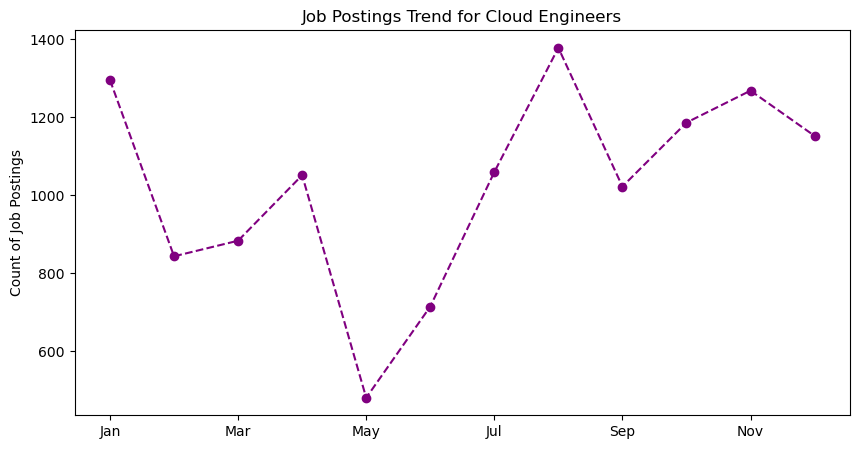

In [2]:
df_ce = df[df['job_title_short'] == 'Cloud Engineer']
df_ce['job_posted_month_no'] = df_ce['job_posted_date'].dt.month
df_ce_pivot = df_ce.pivot_table(index='job_posted_month_no',  aggfunc='size').reset_index(name='job_count')


df_ce_pivot['job_posted_month'] = df_ce_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_ce_pivot = df_ce_pivot.set_index('job_posted_month')
df_ce_pivot = df_ce_pivot.drop(columns='job_posted_month_no')

df_ce_pivot['job_count'].plot(
    kind='line',
    linestyle='--',
    color='purple',
    marker='o',
    figsize=(10, 5)
    )

plt.title('Job Postings Trend for Cloud Engineers')
plt.ylabel('Count of Job Postings')
plt.xlabel('')
plt.show()

---

## 🟨 Customize Bar Chart (2.16.2)

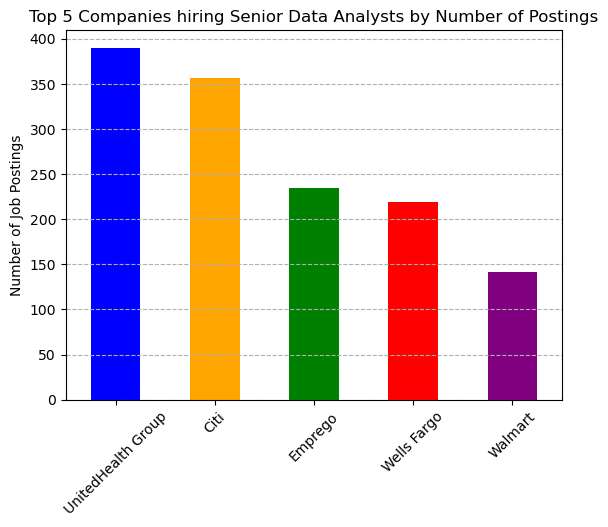

In [8]:
# Code Needed
colors = ['blue', 'orange', 'green', 'red', 'purple']
SDA_df = df[df['job_title_short'] == 'Senior Data Analyst']

top5_SDA = SDA_df['company_name'].value_counts().head(5)

top5_SDA.plot(kind='bar', color=colors)
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45)
plt.xlabel('')
plt.ylabel('Number of Job Postings')
plt.title('Top 5 Companies hiring Senior Data Analysts by Number of Postings')
plt.show()
# plt.bar(top5_SDA.index)


---